In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/P653_pronostico_dataset.csv",sep=";")
df.head()

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [5]:
print("Shape of Dataset:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nStatistical Summary:\n", df.describe())
print("\ninfo:")
df.info()

Shape of Dataset: (6000, 6)

Data Types:
 ID                int64
age             float64
systolic_bp     float64
diastolic_bp    float64
cholesterol     float64
prognosis        object
dtype: object

Missing Values:
 ID              0
age             0
systolic_bp     0
diastolic_bp    0
cholesterol     0
prognosis       0
dtype: int64

Statistical Summary:
                 ID          age  systolic_bp  diastolic_bp  cholesterol
count  6000.000000  6000.000000  6000.000000   6000.000000  6000.000000
mean   2999.500000    60.464121   100.694822     90.505547   100.628255
std    1732.195139     8.564392    10.669267      9.648200    10.433915
min       0.000000    35.164761    69.675429     62.807105    69.967453
25%    1499.750000    54.371941    93.267420     83.641788    93.202373
50%    2999.500000    59.831159   100.119926     89.912429   100.060637
75%    4499.250000    65.809652   107.439501     96.682405   107.250829
max    5999.000000   103.279497   151.699660    133.456382   1

In [6]:
df = df.drop("ID", axis=1) #because id represents the unique id adding it may cause noise

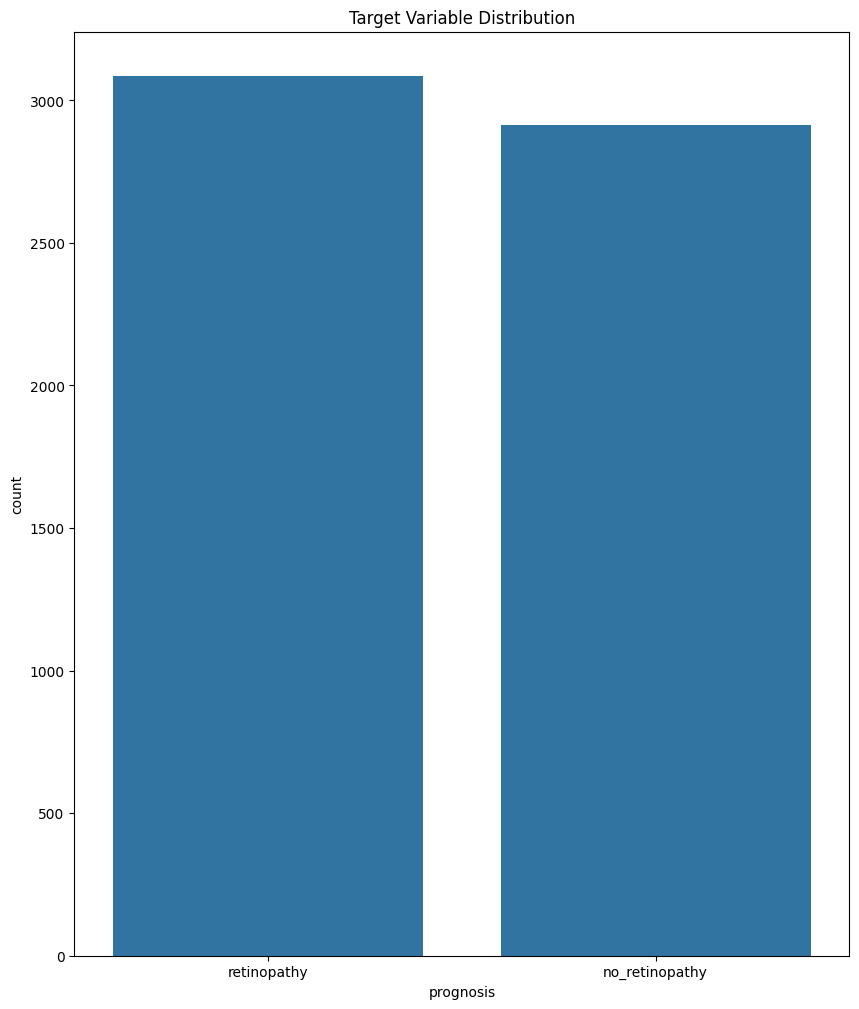

prognosis
retinopathy       51.45
no_retinopathy    48.55
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(10,12))
sns.countplot(x="prognosis", data=df)
plt.title("Target Variable Distribution")
plt.show()

print(df["prognosis"].value_counts(normalize=True)*100)

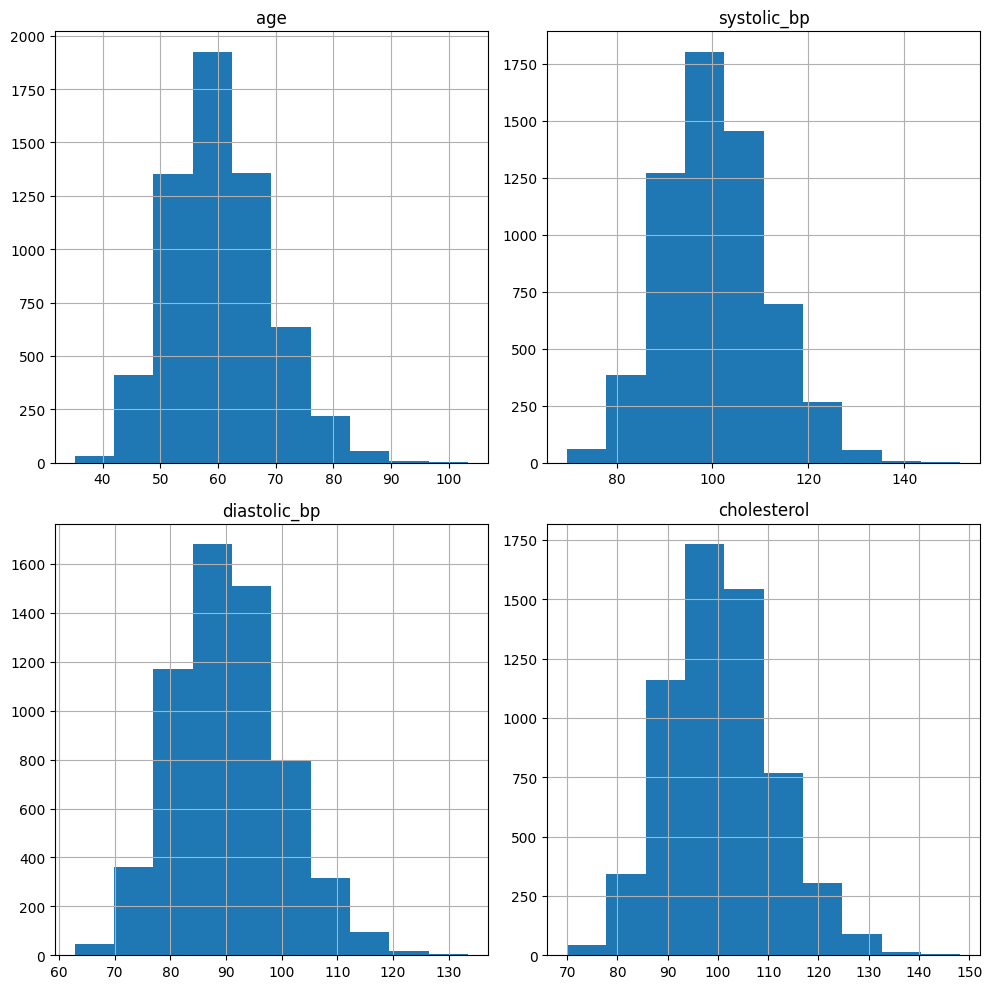

In [10]:
df.hist(figsize=(10,10))
plt.tight_layout()
plt.show()

#use of box plot
Boxplots were used to detect potential outliers in numerical features.The plots help visualize the spread and identify extreme values that may affect model performance.

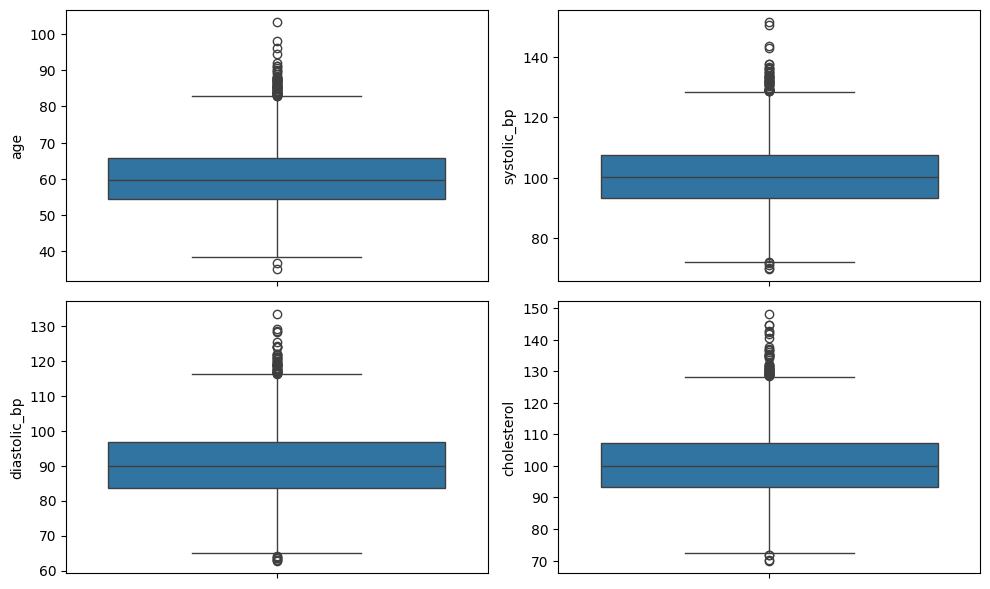

In [12]:
fig, ax = plt.subplots(2,2, figsize=(10,6))
sns.boxplot(y=df["age"], ax=ax[0,0])
sns.boxplot(y=df["systolic_bp"], ax=ax[0,1])
sns.boxplot(y=df["diastolic_bp"], ax=ax[1,0])
sns.boxplot(y=df["cholesterol"], ax=ax[1,1])
plt.tight_layout()
plt.show()

In [14]:
df["prognosis"] = df["prognosis"].map({
    "no_retinopathy":0,
    "retinopathy":1
})

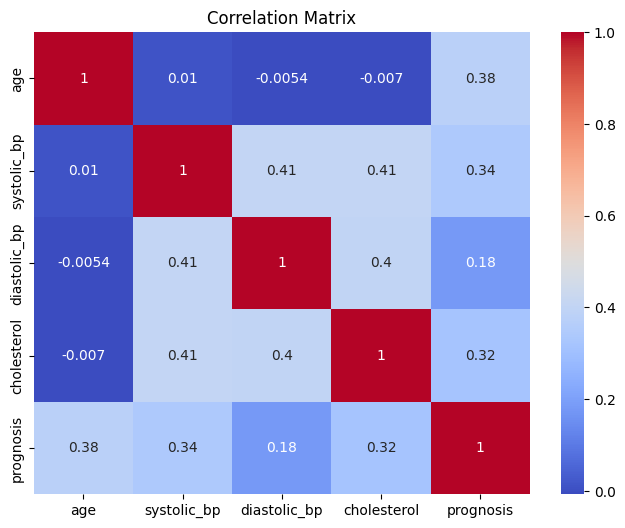

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

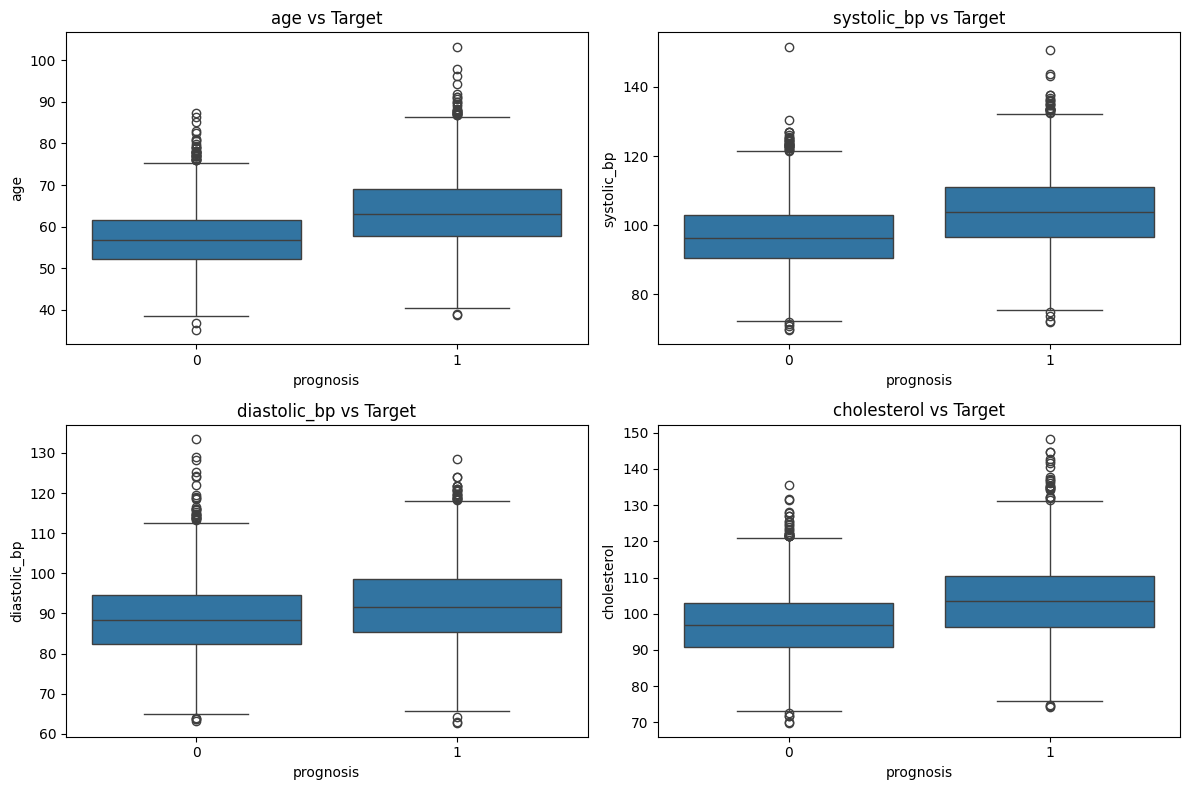

In [16]:
features = df.columns[:-1]

plt.figure(figsize=(12,8))
for i, col in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.boxplot(x="prognosis", y=col, data=df)
    plt.title(f"{col} vs Target")
plt.tight_layout()
plt.show()

In [17]:
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
std_scaler = StandardScaler()
X_standard = std_scaler.fit_transform(X)

X_standard = pd.DataFrame(X_standard, columns=X.columns)

print("Standard Scaled Data:\n")
print(X_standard.describe())

Standard Scaled Data:

                age   systolic_bp  diastolic_bp   cholesterol
count  6.000000e+03  6.000000e+03  6.000000e+03  6.000000e+03
mean  -9.829175e-17  5.708027e-16  1.197265e-15 -2.738550e-16
std    1.000083e+00  1.000083e+00  1.000083e+00  1.000083e+00
min   -2.954263e+00 -2.907602e+00 -2.871080e+00 -2.938816e+00
25%   -7.113975e-01 -6.962073e-01 -7.114623e-01 -7.117656e-01
50%   -7.391242e-02 -5.388787e-02 -6.147959e-02 -5.440584e-02
75%    6.242097e-01  6.322122e-01  6.402617e-01  6.347690e-01
max    4.999648e+00  4.780937e+00  4.452065e+00  4.562933e+00


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Accuracy: 0.7466666666666667
[[428 147]
 [157 468]]
              precision    recall  f1-score   support

           0       0.73      0.74      0.74       575
           1       0.76      0.75      0.75       625

    accuracy                           0.75      1200
   macro avg       0.75      0.75      0.75      1200
weighted avg       0.75      0.75      0.75      1200



In [28]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6908333333333333


In [29]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7366666666666667


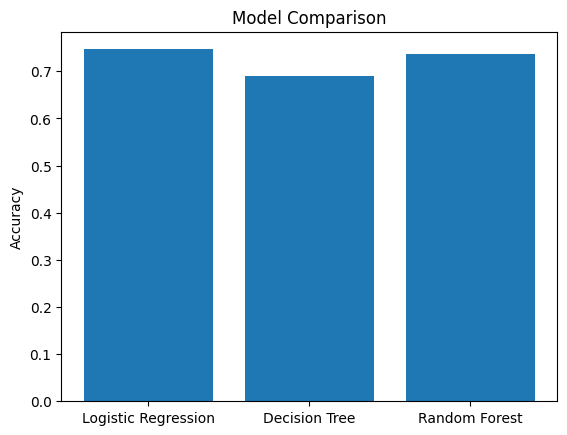

In [30]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [32]:
import joblib
joblib.dump(rf, "retinopathy_model.pkl")
joblib.dump(std_scaler, "scaler.pkl")

['scaler.pkl']

In [41]:
app_code = """
import streamlit as st
import joblib
import numpy as np

# Load model and scaler
model = joblib.load("retinopathy_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Diabetic Retinopathy Prediction")
st.write("Enter patient details to predict diabetic retinopathy.")

# Input fields
age = st.number_input("Age", min_value=1.0, max_value=120.0, value=60.0)
systolic_bp = st.number_input("Systolic Blood Pressure", min_value=50.0, max_value=200.0, value=100.0)
diastolic_bp = st.number_input("Diastolic Blood Pressure", min_value=40.0, max_value=150.0, value=90.0)
cholesterol = st.number_input("Cholesterol", min_value=50.0, max_value=300.0, value=100.0)

if st.button("Predict"):

    input_data = np.array([[age, systolic_bp, diastolic_bp, cholesterol]])
    scaled_data = scaler.transform(input_data)

    prediction = model.predict(scaled_data)
    probability = model.predict_proba(scaled_data)

    st.subheader("Prediction Result")

    if prediction[0] == 1:
        st.error(f"Patient likely has Diabetic Retinopathy (Probability: {probability[0][1]:.2f})")
    else:
        st.success(f"Patient likely does NOT have Diabetic Retinopathy (Probability: {probability[0][0]:.2f})")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py file created successfully!")

app.py file created successfully!
